# EDA — Actividad de Usuario (ActivityLog)

**Fuente real**: colección `ActivityLog` (MongoDB).
Campos reales del esquema (`src/models/mongodb/ActivityLog.js`):
`userId`, `eventType` (search, view_place, view_hotel, save_favorite,
remove_favorite, write_review, book_itinerary, app_open,
wearable_sync), `entityType`, `source` (web, mobile, smartwatch),
`createdAt`.

Este log es justo el que alimenta los mecanismos de ML propuestos sobre
comportamiento (detección de anomalías, destinos emergentes,
comunidades de usuarios) — ver `Docs/UHs`/`proposals.md`.

**Nota**: muestra sintética generada respetando el `enum` real del
schema. Reemplazar por `Data/Raw/activity_log_raw.json` cuando el ETL
esté conectado a MongoDB real.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)


## 1. Carga de datos (sintéticos por ahora — reemplazar por real)

In [2]:
N = 2000

event_types = ['search', 'view_place', 'view_hotel', 'save_favorite',
               'remove_favorite', 'write_review', 'book_itinerary',
               'app_open', 'wearable_sync']
# Pesos que reflejan uso típico: mucho "view_place"/"search", pocos "write_review"
event_weights = [0.20, 0.28, 0.10, 0.08, 0.02, 0.04, 0.05, 0.13, 0.10]

sources = ['web', 'mobile', 'smartwatch']
source_weights = [0.35, 0.45, 0.20]  # wearable pesa menos, coherente con uso puntual

fechas = pd.date_range('2026-05-01', '2026-07-20', periods=N)

df_log = pd.DataFrame({
    'userId': np.random.randint(1, 300, N),
    'eventType': np.random.choice(event_types, N, p=event_weights),
    'source': np.random.choice(sources, N, p=source_weights),
    'createdAt': fechas,
})
df_log.head()


,userId,eventType,source,createdAt
0,153,view_place,web,2026-05-01 00:00:00.000000
1,250,app_open,mobile,2026-05-01 00:57:37.728864
2,132,view_place,mobile,2026-05-01 01:55:15.457728
3,257,wearable_sync,web,2026-05-01 02:52:53.186593
4,278,search,web,2026-05-01 03:50:30.915457


## 2. Frecuencia de eventos por tipo

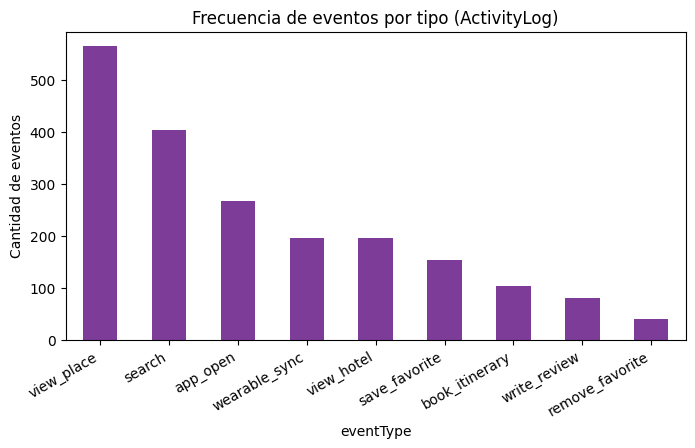

In [3]:
df_log['eventType'].value_counts().plot(kind='bar', figsize=(8,4), color='#7D3C98')
plt.title('Frecuencia de eventos por tipo (ActivityLog)')
plt.ylabel('Cantidad de eventos')
plt.xticks(rotation=30, ha='right')
plt.show()


## 3. Eventos por plataforma (source)

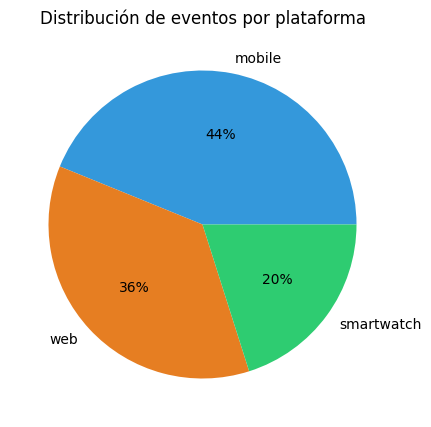

In [4]:
df_log['source'].value_counts().plot(kind='pie', autopct='%1.0f%%', figsize=(5,5),
                                       colors=['#3498DB', '#E67E22', '#2ECC71'])
plt.title('Distribución de eventos por plataforma')
plt.ylabel('')
plt.show()


## 4. Eventos de wearable_sync en el tiempo (patrón de uso del reloj)

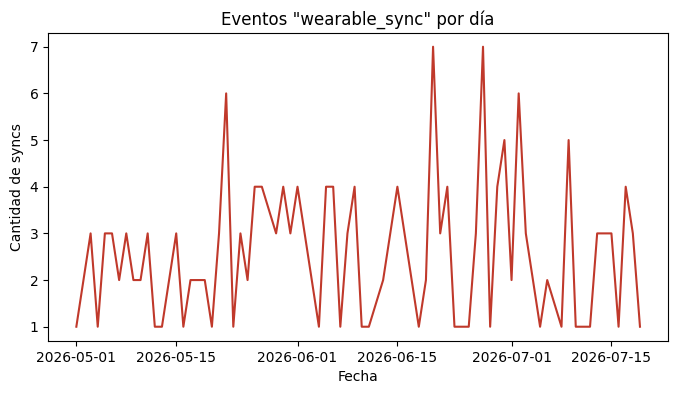

In [5]:
df_wearable = df_log[df_log['eventType'] == 'wearable_sync'].copy()
df_wearable['fecha'] = df_wearable['createdAt'].dt.date
conteo_diario = df_wearable.groupby('fecha').size()

plt.figure(figsize=(8,4))
conteo_diario.plot(color='#C0392B')
plt.title('Eventos "wearable_sync" por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de syncs')
plt.show()


## 5. Cruce: tipo de evento vs. plataforma

In [6]:
tabla_cruzada = pd.crosstab(df_log['eventType'], df_log['source'])
tabla_cruzada


source,mobile,smartwatch,web
eventType,,,
app_open,122,47,98
book_itinerary,50,13,40
remove_favorite,16,11,12
save_favorite,60,39,54
search,176,83,144
view_hotel,82,46,67
view_place,255,107,203
wearable_sync,83,38,74
write_review,33,18,29


## 6. Conclusiones preliminares

- `search` y `view_place` concentran la mayoría de los eventos —
  coherente con un flujo de descubrimiento antes de reservar.
- `wearable_sync` únicamente debería aparecer con `source = smartwatch`
  — si en los datos reales aparece con otro `source`, es señal de un
  bug en el registro (validar en `Tests/Data`).
- El cruce evento×plataforma ayuda a decidir en qué plataforma priorizar
  cada mejora — ej. si `save_favorite` casi no ocurre desde
  `smartwatch`, tiene sentido (pantalla chica, interacción limitada), y
  no se debería forzar esa función ahí.

**Pendiente**: repetir con `activity_log_raw.json` real. Este análisis
es también la base para dos de las 20 propuestas del proyecto
(detección de anomalías de uso y detección de destinos emergentes),
documentadas en `Docs/UHs`.
